# Level 3 - Core Numerical Methods Engine
**ICS 2207 Scientific Computing | HydroSense-Kenya**

**Main Goal:** Implement core numerical root-finding (bisection, Newton-Raphson, secant), finite differences, trapezoidal and Simpson integration, and Gaussian elimination/LU decomposition from scratch. Apply each to real irrigation problems.

In [13]:
import sys 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.numerical_methods import (
    compute_et, compute_et_vectorised, water_balance_step,
    bisection, newton_raphson, secant, irrigation_root_function,
    forward_diff, backward_diff, central_diff, soil_moisture_rate,
    trapezoidal, simpsons, cumulative_water_deficit,
    gaussian_elimination, lu_decomposition, lu_solve, solve_water_allocation
)

weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA',''], parse_dates=['date'])
weather['rainfall_mm']  = weather['rainfall_mm'].interpolate()
weather['humidity_pct'] = weather['humidity_pct'].interpolate()
t_mean = weather['temperature_c'].mean(); t_std = weather['temperature_c'].std()
weather.loc[weather['temperature_c'] > t_mean+3*t_std, 'temperature_c'] = t_mean+3*t_std
params = pd.read_csv('../data/raw/crop_zone_parameters.csv')

T     = weather['temperature_c'].values
W     = weather['wind_speed_mps'].values
Solar = weather['solar_index'].values
H     = weather['humidity_pct'].values
rain  = weather['rainfall_mm'].values
et    = compute_et_vectorised(T, W, Solar, H)

zone_A = params[params['zone_id']=='Zone_A'].iloc[0]
FC = float(zone_A['field_capacity_pct'])
DC = float(zone_A['drainage_coefficient'])
TARGET = float(zone_A['target_moisture_pct'])
MIN_SM = float(zone_A['min_moisture_pct'])
print(f'Zone_A  FC={FC}%  DC={DC}  Target={TARGET}%  Min={MIN_SM}%')
print(f'ET computed for {len(et)} days, mean={et.mean():.3f} mm/day')


Zone_A  FC=41.0%  DC=0.18  Target=33.0%  Min=22.0%
ET computed for 30 days, mean=3.716 mm/day


In [14]:
S_t  = 24.0   # current soil moisture (%)
R_t  = 0.0    # no rain today
ET_t = et[16] # use day-17 ET as representative dry-day value
print(f'Scenario: S={S_t}%, Rain={R_t}mm, ET={ET_t:.3f}mm, FC={FC}%, DC={DC}')
print(f'Target moisture: {TARGET}%')

def f_irrig(I):
    return irrigation_root_function(I, S_t, R_t, ET_t, FC, DC, TARGET)

# Derivative for Newton-Raphson (numerical)
def df_irrig(I, h=1e-5):
    return (f_irrig(I+h) - f_irrig(I-h)) / (2*h)

# Run all three methods 
res_bi = bisection(f_irrig, 0.0, 20.0, tol=1e-6)
res_nr = newton_raphson(f_irrig, df_irrig, x0=5.0, tol=1e-6)
res_sc = secant(f_irrig, 0.5, 5.0, tol=1e-6)

print()
print(f'Method           Root (mm)    Iterations   Final Error   Converged')
for name, res in [('Bisection',res_bi),('Newton-Raphson',res_nr),('Secant',res_sc)]:
    print(f'{name:<16} {res["root"]:.6f}    {res["iterations"]:<12} {res["final_error"]:.2e}    {res["converged"]}')

print(f'\nIrrigation needed: {res_bi["root"]:.3f} mm  to lift Zone_A from {S_t}% to {TARGET}%')
S_check, D = water_balance_step(S_t, R_t, res_bi['root'], ET_t, FC, DC)
print(f'Verification: S(t+1) = {S_check:.4f}%  (target={TARGET}%)')


Scenario: S=24.0%, Rain=0.0mm, ET=3.530mm, FC=41.0%, DC=0.18
Target moisture: 33.0%

Method           Root (mm)    Iterations   Final Error   Converged
Bisection        12.530500    25           5.96e-07    True
Newton-Raphson   12.530500    2            2.85e-10    True
Secant           12.530500    2            0.00e+00    True

Irrigation needed: 12.531 mm  to lift Zone_A from 24.0% to 33.0%
Verification: S(t+1) = 33.0000%  (target=33.0%)


## 3. Convergence Analysis and Comparison Plot

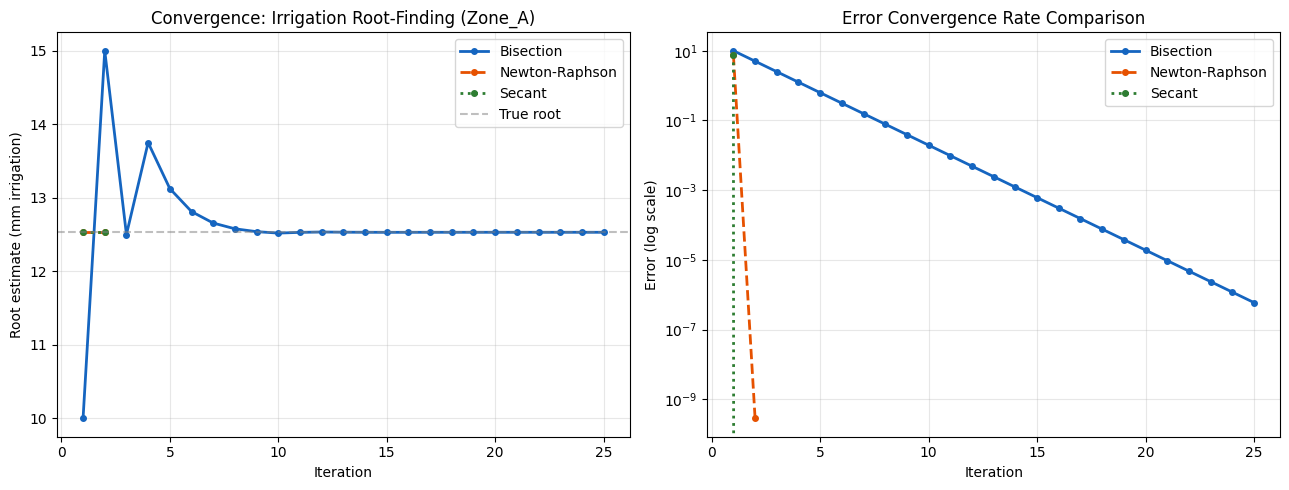

Scientific interpretation: Newton-Raphson and Secant converge super-linearly
(error roughly squares each step), while Bisection converges linearly.
For irrigation decisions where fast convergence reduces compute cost, Newton-Raphson is preferred.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Convergence: root estimate per iteration
for name, res, col, ls in [
    ('Bisection',    res_bi, '#1565C0', '-'),
    ('Newton-Raphson', res_nr, '#E65100', '--'),
    ('Secant',       res_sc, '#2E7D32', ':')]:
    iters = [h['iter'] for h in res['history']]
    roots = [h['root_est'] for h in res['history']]
    axes[0].plot(iters, roots, color=col, ls=ls, lw=2, marker='o', ms=4, label=name)

axes[0].axhline(res_bi['root'], color='grey', ls='--', alpha=0.5, label='True root')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Root estimate (mm irrigation)')
axes[0].set_title('Convergence: Irrigation Root-Finding (Zone_A)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Error convergence (log scale)
for name, res, col, ls in [
    ('Bisection',    res_bi, '#1565C0', '-'),
    ('Newton-Raphson', res_nr, '#E65100', '--'),
    ('Secant',       res_sc, '#2E7D32', ':')]:
    iters  = [h['iter'] for h in res['history']]
    errors = [h['error'] for h in res['history']]
    axes[1].semilogy(iters, errors, color=col, ls=ls, lw=2, marker='o', ms=4, label=name)

axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Error (log scale)')
axes[1].set_title('Error Convergence Rate Comparison')
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()
print('Scientific interpretation: Newton-Raphson and Secant converge super-linearly')
print('(error roughly squares each step), while Bisection converges linearly.')
print('For irrigation decisions where fast convergence reduces compute cost, Newton-Raphson is preferred.')


## 4. Finite Differences - Rate of Soil Moisture Change

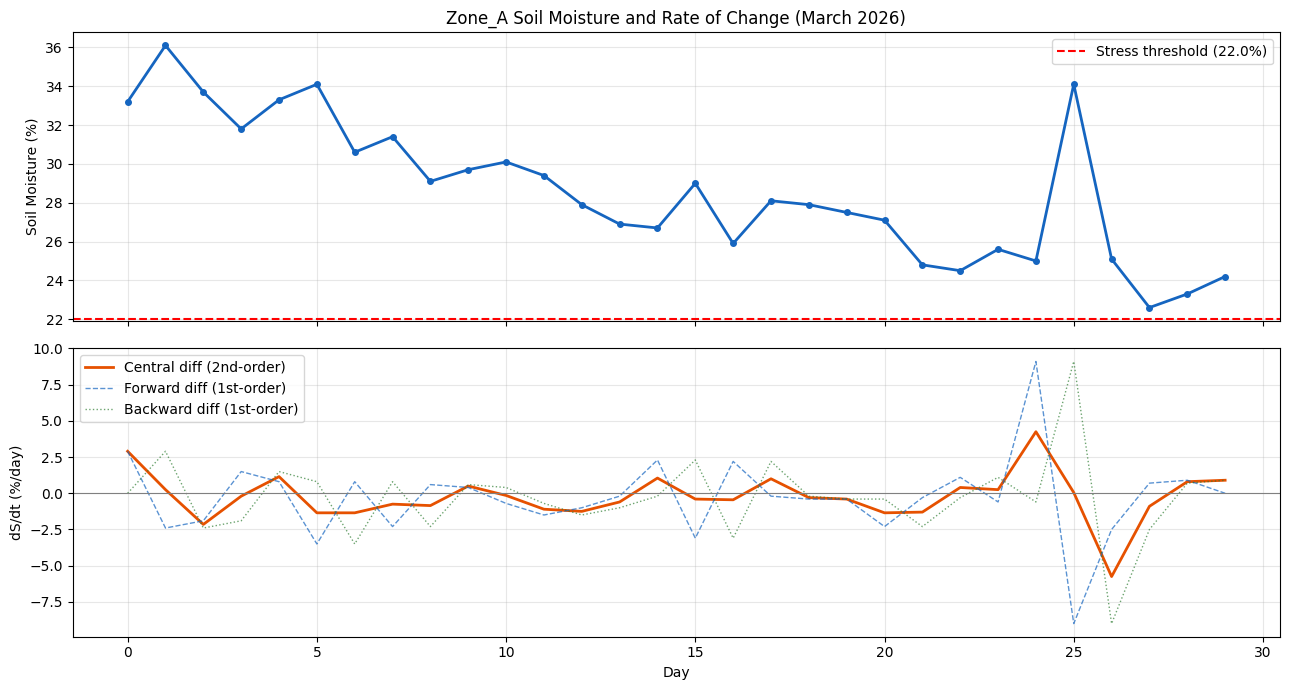

Central differences are 2nd-order accurate (error O(h^2)) vs 1st-order for forward/backward.
Days with negative dS/dt (drying): 18
Days with positive dS/dt (wetting from rain): 12


In [16]:
soil = pd.read_csv('../data/raw/soil_sensor_data.csv', na_values=['NA',''], parse_dates=['timestamp'])
soil['soil_moisture_pct'] = soil.groupby('zone_id')['soil_moisture_pct'].transform(lambda s: s.ffill().bfill())
soil_A = soil[soil['zone_id']=='Zone_A'].sort_values('timestamp')['soil_moisture_pct'].values

# Element-wise finite differences
n = len(soil_A)
fwd  = np.array([forward_diff(lambda x: np.interp(x, np.arange(n), soil_A), float(i)) for i in range(n)])
bwd  = np.array([backward_diff(lambda x: np.interp(x, np.arange(n), soil_A), float(i)) for i in range(n)])
cen  = soil_moisture_rate(soil_A)  # our efficient vectorised version

days = np.arange(n)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(days, soil_A, color='#1565C0', lw=2, marker='o', ms=4)
axes[0].set_ylabel('Soil Moisture (%)'); axes[0].set_title('Zone_A Soil Moisture and Rate of Change (March 2026)')
axes[0].axhline(MIN_SM, color='red', ls='--', lw=1.5, label=f'Stress threshold ({MIN_SM}%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(days, cen, color='#E65100', lw=2, label='Central diff (2nd-order)')
axes[1].plot(days, fwd, color='#1565C0', lw=1, ls='--', alpha=0.7, label='Forward diff (1st-order)')
axes[1].plot(days, bwd, color='#2E7D32', lw=1, ls=':', alpha=0.7, label='Backward diff (1st-order)')
axes[1].axhline(0, color='grey', ls='-', lw=0.8)
axes[1].set_xlabel('Day'); axes[1].set_ylabel('dS/dt (%/day)')
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()
print('Central differences are 2nd-order accurate (error O(h^2)) vs 1st-order for forward/backward.')
print(f'Days with negative dS/dt (drying): {(cen<0).sum()}')
print(f'Days with positive dS/dt (wetting from rain): {(cen>0).sum()}')


## 5. Numerical Integration - Cumulative Water Deficit

Integration Comparison: Cumulative 30-Day Water Deficit
Method            Result (mm)    vs NumPy (mm)   Difference
Trapezoidal       44.3147         44.3147          0.00e+00
Simpsons          46.3672         --              --
Difference:       2.0525 mm (Simpson usually more accurate for smooth functions)


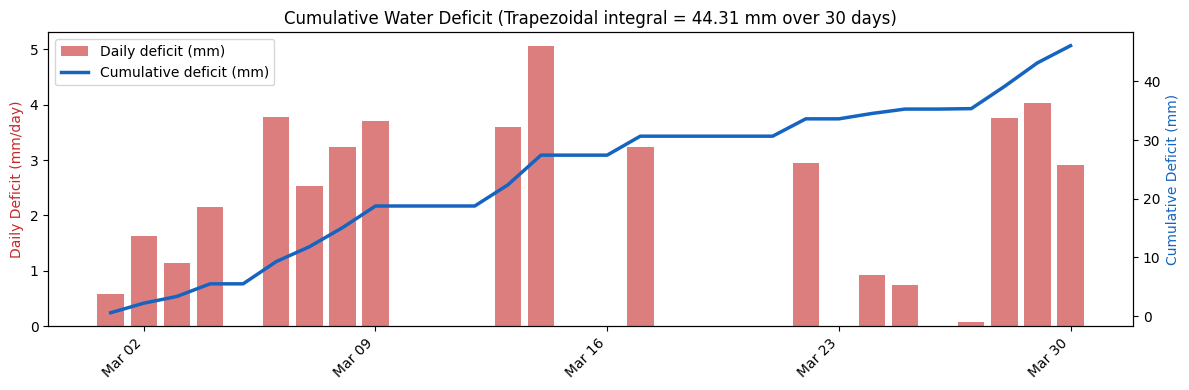

In [17]:
deficit = np.maximum(0, et - rain)

trap_result = trapezoidal(deficit, dx=1.0)
simp_result = simpsons(deficit, dx=1.0)

# Also compute with numpy for verification
_trapz = getattr(np, 'trapezoid', None) or np.trapz
np_trap = float(_trapz(deficit, dx=1.0))

print('Integration Comparison: Cumulative 30-Day Water Deficit')
print(f'Method            Result (mm)    vs NumPy (mm)   Difference')
print(f'Trapezoidal       {trap_result:.4f}         {np_trap:.4f}          {abs(trap_result-np_trap):.2e}')
print(f'Simpsons          {simp_result:.4f}         --              --')
print(f'Difference:       {abs(simp_result-trap_result):.4f} mm (Simpson usually more accurate for smooth functions)')

# Cumulative plot
daily_def, cum_def = cumulative_water_deficit(et, rain)
fig, ax = plt.subplots(figsize=(12, 4))
dates = weather['date'].values
ax2 = ax.twinx()
ax.bar(dates, daily_def, color='#C62828', alpha=0.6, label='Daily deficit (mm)')
ax2.plot(dates, np.cumsum(daily_def), color='#1565C0', lw=2.5, label='Cumulative deficit (mm)')
ax.set_ylabel('Daily Deficit (mm/day)', color='#C62828')
ax2.set_ylabel('Cumulative Deficit (mm)', color='#1565C0')
ax.set_title(f'Cumulative Water Deficit (Trapezoidal integral = {trap_result:.2f} mm over 30 days)')
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
lines1,labs1 = ax.get_legend_handles_labels()
lines2,labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, loc='upper left')
fig.tight_layout()
plt.show()


## 6. Linear Systems - Three-Zone Water Allocation

In [18]:
# Problem: allocate daily pump water W_total among three zones
# Zone constraints as a linear system Ax = b:
#   x1 + x2 + x3  = W_total       (total allocation)
#   120*x1 - 90*x2 = 0            (proportional to area: Zone_A:Zone_B)
#   180*x2 - 90*x3 = 0            (proportional to area: Zone_B:Zone_C)
# where x1, x2, x3 = mm/day allocated to Zone_A, B, C

areas = {'Zone_A': 120.0, 'Zone_B': 90.0, 'Zone_C': 180.0}
W_total = 30.0  # total mm/day available from pump

A = np.array([
    [1.0,          1.0,         1.0],
    [areas['Zone_A'], -areas['Zone_B'], 0.0],
    [0.0,          areas['Zone_B'], -areas['Zone_C']]
], dtype=float)

b = np.array([W_total, 0.0, 0.0], dtype=float)

# Solve with our Gaussian elimination
x_gauss = solve_water_allocation(A, b, method='gaussian')

# Solve with our LU decomposition
x_lu = solve_water_allocation(A, b, method='lu')

# Verify with NumPy
x_np = np.linalg.solve(A, b)

print('Three-Zone Water Allocation: Ax = b Solution')
print(f'Total water available: {W_total} mm/day')
print()
print(f'Method         Zone_A (mm)  Zone_B (mm)  Zone_C (mm)  Sum (mm)')
for name, x in [('Gaussian', x_gauss), ('LU', x_lu), ('NumPy (ref)', x_np)]:
    print(f'{name:<14} {x[0]:.4f}      {x[1]:.4f}      {x[2]:.4f}      {x.sum():.4f}')
print()
print('Area-proportional check:')
print(f'  Zone_A/Zone_B ratio: {x_gauss[0]/x_gauss[1]:.3f}  (expected {areas["Zone_B"]/areas["Zone_A"]:.3f})')
print(f'  Zone_B/Zone_C ratio: {x_gauss[1]/x_gauss[2]:.3f}  (expected {areas["Zone_C"]/areas["Zone_B"]:.3f})')
print(f'  Gauss vs NumPy max diff: {np.max(np.abs(x_gauss-x_np)):.2e}')
print(f'  LU    vs NumPy max diff: {np.max(np.abs(x_lu-x_np)):.2e}')
print()
print('Interpretation: Water is allocated proportionally to zone area.')
print('Larger Zone_C (maize, 180m2) receives approximately twice the allocation of Zone_B.')


Three-Zone Water Allocation: Ax = b Solution
Total water available: 30.0 mm/day

Method         Zone_A (mm)  Zone_B (mm)  Zone_C (mm)  Sum (mm)
Gaussian       10.0000      13.3333      6.6667      30.0000
LU             10.0000      13.3333      6.6667      30.0000
NumPy (ref)    10.0000      13.3333      6.6667      30.0000

Area-proportional check:
  Zone_A/Zone_B ratio: 0.750  (expected 0.750)
  Zone_B/Zone_C ratio: 2.000  (expected 2.000)
  Gauss vs NumPy max diff: 0.00e+00
  LU    vs NumPy max diff: 8.88e-16

Interpretation: Water is allocated proportionally to zone area.
Larger Zone_C (maize, 180m2) receives approximately twice the allocation of Zone_B.
